# **Atelier Préparation de Données Textuelles**

### **Contexte** 
Une entreprise souhaite développer un système capable de classer automatiquement des avis 
clients afin d'identifier leur sentiment. 
Les avis proviennent de plusieurs sources : site web, application mobile, formulaire de satisfaction, 
réseaux sociaux et service client. 
Les données collectées sont cependant de qualité variable : textes vides, doublons, fautes de frappe, 
majuscules/minuscules, caractères spéciaux, emojis, URLs, mentions, répétitions de caractères, 
textes très courts ou très longs, plusieurs catégories de sentiment et quelques valeurs manquantes. 
Avant de construire un modèle de Machine Learning ou de Deep Learning, les apprenants doivent 
donc construire un pipeline complet de préparation des données textuelles. 

---
## **Partie 1 – Exploration du corpus**

### **1) Charger les données CSV**

In [2]:
import pandas as pd

df = pd.read_csv("../data/smart_reviews_raw.csv")
df.head()

,id_avis,date,source,produit,texte,sentiment,note,langue
0,AV0001,2026-02-27,mobile,Ordinateur NovaBook,"Très bonne expérience, simple et efficace.",positif,4,fr
1,AV0002,2026-01-09,web,SmartPhone X,Très satisfait de mon achat 👍 #avis,positif,4,fr
2,AV0003,2026-07-03,réseaux_sociaux,Écouteurs AirSound,"Produit parfait, rien à signaler.",positif,4,fr
3,AV0004,2026-06-28,sav,SmartWatch Pro,"Produit excellent, je suis très satisfait. !!!",positif,5,fr
4,AV0005,2026-01-24,sav,SmartPhone X,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,positif,5,fr


### **2) Combien d'avis contient le dataset ?**

In [3]:
print(f"Le dataset contient {len(df)} avis.")

Le dataset contient 1200 avis.


### **3) Combien de colonnes possède-t-il ?**

In [4]:
print(f"Le dataset possède {df.shape[1]} colonnes.")
print("Colonnes :", df.columns.tolist())

Le dataset possède 8 colonnes.
Colonnes : ['id_avis', 'date', 'source', 'produit', 'texte', 'sentiment', 'note', 'langue']


### **4) Quel est le type de chaque colonne ?**

In [5]:
print(df.dtypes)

id_avis        str
date           str
source         str
produit        str
texte          str
sentiment      str
note         int64
langue         str
dtype: object


### **5) Existe-t-il des valeurs manquantes ?**

In [6]:
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())
print("\nTotal de valeurs manquantes :", df.isnull().sum().sum())

Valeurs manquantes par colonne :
id_avis      0
date         0
source       0
produit      0
texte        5
sentiment    0
note         0
langue       0
dtype: int64

Total de valeurs manquantes : 5


### **6) Identifier quelques types de texte**

In [7]:
# Texte normal
print("=== Texte normal ===")
print(df.loc[0, "texte"])

=== Texte normal ===
Très  bonne  expérience,  simple  et  efficace.


In [8]:
# Texte vide / NaN
print("\n=== Texte vide / NaN ===")
print(df[df["texte"].isna() | (df["texte"].astype(str).str.strip() == "")]["texte"].head(3))



=== Texte vide / NaN ===
46     NaN
108    NaN
310    NaN
Name: texte, dtype: str


In [9]:
# Texte contenant une URL
print("\n=== Texte avec URL ===")
print(df[df["texte"].astype(str).str.contains(r"https?://", na=False)]["texte"].head(2).tolist())



=== Texte avec URL ===
['Produit parfait, rien à signaler. https://example.com/commande/17', 'Très bonne expérience, simple et efficace. https://example.com/commande/31']


In [10]:
# Texte contenant une mention
print("\n=== Texte avec mention ===")
print(df[df["texte"].astype(str).str.contains(r"@\w+", na=False)]["texte"].head(2).tolist())


=== Texte avec mention ===
['@client Livraison rapide et produit conforme à mes attentes.', '@client Service client réactif et commande reçue rapidement.']


In [11]:
# Texte contenant un hashtag
print("\n=== Texte avec hashtag ===")
print(df[df["texte"].astype(str).str.contains(r"#\w+", na=False)]["texte"].head(2).tolist())



=== Texte avec hashtag ===
['Très satisfait de mon achat 👍 #avis', "La batterie tient vraiment bien et l'écran est superbe. #avis"]


In [12]:
# Texte contenant des emojis
print("\n=== Texte avec emojis ===")
print(df[df["texte"].astype(str).str.contains(r"[👍😊😡]", na=False)]["texte"].head(2).tolist())



=== Texte avec emojis ===
['Très satisfait de mon achat 👍 #avis', 'Très satisfait de mon achat 👍 😊']


In [23]:
# Texte avec beaucoup de ponctuation
print("\n=== Texte avec beaucoup de ponctuation ===")
print(df[df["texte"].astype(str).str.contains(r"!!!", na=False)]["texte"].head(2).tolist())



=== Texte avec beaucoup de ponctuation ===
['Produit excellent, je suis très satisfait. !!!', 'Très satisfait de mon achat 👍 !!!']


In [14]:
# Texte en majuscules
print("\n=== Texte en majuscules ===")
print(df[df["texte"].astype(str).str.isupper()]["texte"].head(2).tolist())



=== Texte en majuscules ===
["LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE.", 'SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPIDEMENT.']


In [15]:
# Texte avec répétition de caractères
print("\n=== Texte avec répétition de caractères ===")
print(df[df["texte"].astype(str).str.contains(r"(.)\1{2,}", na=False)]["texte"].head(2).tolist())


=== Texte avec répétition de caractères ===
['Produit excellent, je suis très satisfait. !!!', 'Très satisfait de mon achat 👍 !!!']


C:\Users\HP\AppData\Local\Temp\ipykernel_24172\1618673901.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  print(df[df["texte"].astype(str).str.contains(r"(.)\1{2,}", na=False)]["texte"].head(2).tolist())


### **7) Mesurer la longueur des textes**

In [16]:
# Remplacer les NaN par chaîne vide
df["texte"] = df["texte"].fillna("")

# Calculer la longueur en évitant les erreurs
df["longueur"] = df["texte"].astype(str).apply(lambda x: len(x.strip()))
print("Longueur minimale :", df["longueur"].min())
print("Longueur maximale :", df["longueur"].max())
print("Longueur moyenne  :", round(df["longueur"].mean(), 2))
print("Médiane           :", df["longueur"].median())
print("\nQuartiles :")
print(df["longueur"].quantile([0.25, 0.5, 0.75]))


Longueur minimale : 0
Longueur maximale : 635
Longueur moyenne  : 48.96
Médiane           : 48.0

Quartiles :
0.25    37.0
0.50    48.0
0.75    56.0
Name: longueur, dtype: float64


### **8) Visualiser la distribution de la longueur des avis**

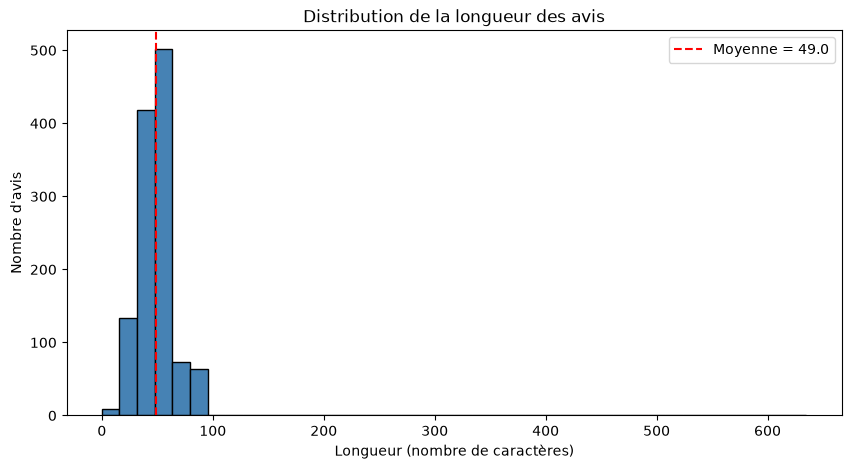

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(df["longueur"], bins=40, edgecolor="black", color="steelblue")
plt.title("Distribution de la longueur des avis")
plt.xlabel("Longueur (nombre de caractères)")
plt.ylabel("Nombre d'avis")
plt.axvline(df["longueur"].mean(), color="red", linestyle="--", label=f"Moyenne = {df['longueur'].mean():.1f}")
plt.legend()
plt.show()

### **Réponses aux questions :**

#### a) **Existe-t-il des textes anormalement longs ?**  
Oui, quelques textes dépassent largement la moyenne (plus de 100 caractères), mais dans l'ensemble les longueurs restent raisonnables pour des avis clients.

#### b) **Existe-t-il beaucoup de textes très courts ?**  
Oui, on observe une concentration de textes très courts (moins de 20-30 caractères), notamment des textes vides, des "OK" ou des messages très brefs.

### **9) Détecter les textes vides**

In [18]:
textes_vides = df[df["texte"].isna() | (df["texte"].astype(str).str.strip() == "")]
print(f"Nombre de textes vides ou NaN : {len(textes_vides)}")
textes_vides[["id_avis", "texte"]]

Nombre de textes vides ou NaN : 6


,id_avis,texte
46,AV0047,
108,AV0109,
310,AV0311,
640,AV0641,
781,AV0782,
951,AV0952,


### **10) Détecter les doublons sur le texte**

In [19]:
nb_doublons = df.duplicated(subset=["texte"]).sum()
print(f"Nombre de doublons exacts sur la colonne texte : {nb_doublons}")

# Afficher quelques exemples de textes qui apparaissent plusieurs fois
doublons = df[df.duplicated(subset=["texte"], keep=False)].groupby("texte").size().sort_values(ascending=False)
print("\nExemples de textes les plus répétés :")
print(doublons.head(10))

Nombre de doublons exacts sur la colonne texte : 881

Exemples de textes les plus répétés :
texte
Excellent rapport qualité-prix.                                  29
Livraison rapide et produit conforme à mes attentes.             19
Très satisfait de mon achat 👍                                    19
Très bon produit, la qualité est au rendez-vous.                 19
EXCELLENT RAPPORT QUALITÉ-PRIX.                                  16
Je viens de recevoir le produit, à voir dans le temps.           16
@client Service client réactif et commande reçue rapidement.     16
LIVRAISON RAPIDE ET PRODUIT CONFORME À MES ATTENTES.             16
La batterie tient vraiment bien et l'écran est superbe. #avis    15
Très bonne expérience, simple et efficace.                       15
dtype: int64


### **11) Les classes sont-elles équilibrées ?**

In [20]:
print(df["sentiment"].value_counts())
print("\nRépartition en pourcentage :")
print((df["sentiment"].value_counts(normalize=True) * 100).round(2))

sentiment
positif    776
neutre     246
negatif    178
Name: count, dtype: int64

Répartition en pourcentage :
sentiment
positif    64.67
neutre     20.50
negatif    14.83
Name: proportion, dtype: float64


#### **Réponse :** 
Non, les classes ne sont pas équilibrées. La classe `positif` domine largement.

### **12) Quelle est la classe majoritaire ?**

In [21]:
classe_maj = df["sentiment"].value_counts().idxmax()
print(f"La classe majoritaire est : {classe_maj}")

La classe majoritaire est : positif


### **13) Quelles métriques de classification à envisager d'utiliser ?**

Comme les classes sont déséquilibrées, l'**accuracy** seule n'est pas suffisante.  
On privilégiera :
- **F1-score** (macro ou weighted)
- **Precision** et **Recall** par classe
- **Matrice de confusion**
- Éventuellement **balanced accuracy**

### **14) Détecter les caractères particuliers**

In [27]:
import re
motifs = {
    "emojis": r'[\U0001F300-\U0001FAFF\u2600-\u27BF]',
    "URLs": r'https?://\S+',
    "hashtags": r'#\w+',
    "mentions": r'@\w+',
    "chiffres": r'\d',
    "caractères spéciaux (hors lettres/accents/espaces)": r'[^\w\sÀ-ÿ]',
    "ponctuation répétée (!!, ??, ...)": r'([!?.,])\1{1,}',
}

texte = df["texte"].astype(str)

for nom, motif in motifs.items():
    n_occurrences = texte.apply(lambda t: len(re.findall(motif, t))).sum()
    n_avis_concernes = texte.apply(lambda t: bool(re.search(motif, t))).sum()
    print(f"{nom:55s} -> {n_occurrences:4d} occurrences dans {n_avis_concernes:4d} avis")


emojis                                                  ->  205 occurrences dans  192 avis
URLs                                                    ->  143 occurrences dans  143 avis
hashtags                                                ->  127 occurrences dans  127 avis
mentions                                                ->  128 occurrences dans  128 avis
chiffres                                                ->  441 occurrences dans  142 avis
caractères spéciaux (hors lettres/accents/espaces)      -> 3709 occurrences dans 1190 avis
ponctuation répétée (!!, ??, ...)                       ->  141 occurrences dans  141 avis


### **15) Visualiser et commenter le nombre d'avis par source**

source
réseaux_sociaux    251
email              247
sav                239
web                232
mobile             230
WEB                  1
Name: count, dtype: int64


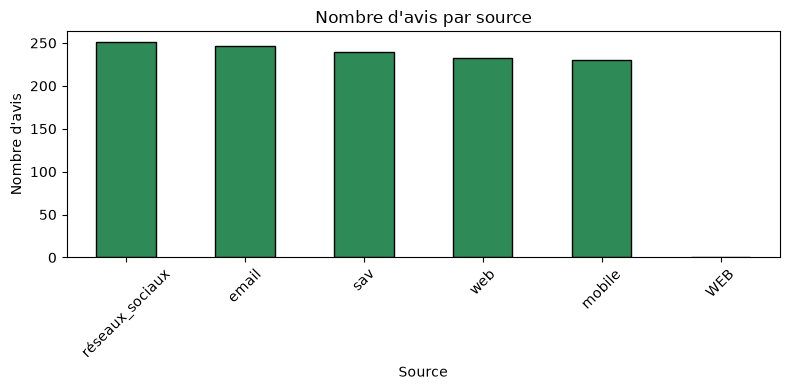

In [35]:
counts_source = df["source"].value_counts()
print(counts_source)

plt.figure(figsize=(8, 4))
counts_source.plot(kind="bar", color="seagreen", edgecolor="black")
plt.title("Nombre d'avis par source")
plt.xlabel("Source")
plt.ylabel("Nombre d'avis")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### **Commentaire**
Les 5 sources (**web**, **mobile**, **réseaux_sociaux**, **sav** et **email**) sont relativement bien réparties, avec environ 230 à 250 avis par source. On remarque toutefois la présence de **WEB** en majuscules, en plus de **web**. Il s’agit d’une différence d’écriture pour désigner la même source. Cette incohérence devra être corrigée lors du nettoyage des données afin d’harmoniser les valeurs.

